# DAG Model Comparison

Compare NWP model fields (HRRR, RAP, NBM, NAM, GFS, IFS, HREF, etc.) against RTMA analysis.

This notebook downloads GRIB data via [Herbie](https://herbie.readthedocs.io/), regrids with xESMF, computes the difference, and plots the result over CONUS.

## 0 — Environment Setup

**If running on Google Colab**, uncomment and run the cell below to install conda and the required dependencies. This takes ~2-3 minutes. Skip this cell if running locally with the conda environment already activated.

In [27]:
# --- Colab-only setup (uncomment to use) ---
# !pip install -q condacolab
# import condacolab
# condacolab.install()  # This restarts the runtime automatically

In [28]:
# --- Colab-only: install deps after condacolab restart (uncomment to use) ---
# !mamba install -y -c conda-forge xesmf esmf esmpy xarray numpy matplotlib metpy pyproj cartopy herbie-data pandas scipy pyyaml

In [29]:
import sys
print(sys.executable)

/opt/conda/envs/new_comparator/bin/python


## 1 — Imports

In [30]:
%matplotlib inline

from herbie.core import Herbie
import xesmf as xe
import matplotlib.pyplot as plt
from comparator import fielddiff as fd
from comparator import plotting as plot
from comparator import util
from comparator import normalize as norm
from datetime import datetime, timedelta
from pathlib import Path

## 2 — Configuration

Edit the variables below to select your model, date, and field.

In [31]:
# --- User configuration ---
NWP_MODEL   = "HREF"        # Options: HRRR, RAP, NBM, NAM5K, NAM12K, ARW, FV3, GFS, IFS, HREF
DATE        = "2026-03-20"  # YYYY-MM-DD
INIT_HOUR   = 00            # Initialization hour (00-23, Z-time)
FORECAST_HR = 24             # Forecast lead time in hours
ANL_VAR     = "TMP"         # TMP = 2m temperature, DPT = 2m dew point

DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)

## 3 — Resolve Model & Variable Keys

In [32]:
model_key = norm.normalize_model_key(NWP_MODEL)
var_key   = norm.normalize_var_key(ANL_VAR)
var_meta  = norm.VAR_REGISTRY[var_key]

nwp_kwargs = norm.herbie_kwargs_for(model_key)
selector   = norm.get_selector(model_key, var_key)

cycle_dt = datetime.fromisoformat(f"{DATE} {INIT_HOUR:02d}:00")
valid_dt = cycle_dt + timedelta(hours=FORECAST_HR)

print(f"Model:    {model_key.upper()}")
print(f"Variable: {var_meta['title']}")
print(f"Cycle:    {cycle_dt:%Y-%m-%d %H:%MZ}")
print(f"Valid:    {valid_dt:%Y-%m-%d %H:%MZ}")

Model:    HREF
Variable: 2 Meter Temperature
Cycle:    2026-03-20 00:00Z
Valid:    2026-03-21 00:00Z


## 4 — Download GRIB Data

In [33]:
# NWP model field
nwp = Herbie(
    cycle_dt,
    fxx=FORECAST_HR,
    save_dir=str(DATA_DIR),
    overwrite=True,
    **nwp_kwargs,
)

# RTMA analysis at valid time
rtma_kwargs = norm.herbie_kwargs_for("rtma")
rtma = Herbie(
    valid_dt,
    fxx=0,
    save_dir=str(DATA_DIR),
    overwrite=True,
    **rtma_kwargs,
)

print(f"NWP source:  {nwp}")
print(f"RTMA source: {rtma}")

✅ Found ┊ model=href ┊ product=mean ┊ 2026-Mar-20 00:00 UTC F24 ┊ GRIB2 @ nomads ┊ IDX @ nomads
✅ Found ┊ model=rtma ┊ product=anl ┊ 2026-Mar-21 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws
NWP source:  ║HERBIE╠ HREF:mean
RTMA source: ║HERBIE╠ RTMA:anl


## 5 — Load Fields into xarray

In [34]:
nwp_xr_kwargs = norm.get_xarray_kwargs(model_key)
ds_nwp = norm.ensure_dataset(
    nwp.xarray(selector, remove_grib=True, **nwp_xr_kwargs),
    var_key=var_key,
)
ds_nwp = norm.wrap_longitude(ds_nwp)

rtma_selector = norm.get_selector("rtma", var_key)
ds_rtma = norm.ensure_dataset(
    rtma.xarray(rtma_selector, remove_grib=True),
    var_key=var_key,
)

nwp_varname  = norm.pick_data_varname_from_ds(ds_nwp, var_key)
rtma_varname = norm.pick_data_varname_from_ds(ds_rtma, var_key)

print(f"NWP  variable: {nwp_varname}  shape: {ds_nwp[nwp_varname].shape}")
print(f"RTMA variable: {rtma_varname} shape: {ds_rtma[rtma_varname].shape}")

NWP  variable: t2m  shape: (1025, 1473)
RTMA variable: t2m shape: (1597, 2345)


## 6 — Regrid RTMA to Model Grid

In [35]:
src_grid = {"lon": ds_rtma["longitude"], "lat": ds_rtma["latitude"]}
tgt_grid = {"lon": ds_nwp["longitude"],  "lat": ds_nwp["latitude"]}

regridder = xe.Regridder(
    src_grid, tgt_grid, method="bilinear", periodic=False, reuse_weights=False
)
rtma_on_nwp = regridder(ds_rtma[rtma_varname])

print(f"Regridded RTMA shape: {rtma_on_nwp.shape}")

Regridded RTMA shape: (1025, 1473)


## 7 — Compute Field Difference

In [36]:
diff = fd.compute_fielddiff(ds_nwp[nwp_varname], rtma_on_nwp)
print(f"Diff shape: {diff.shape}")

Diff shape: (1025, 1473)


## 8 — Plot Results

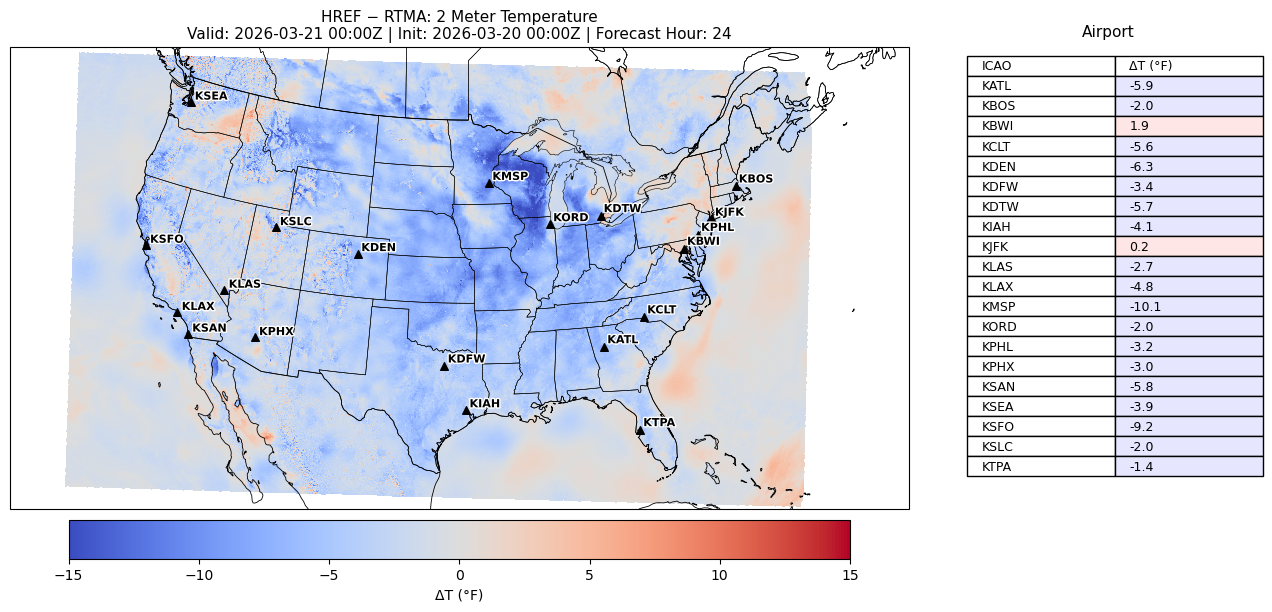

In [37]:
airports = util.major_airports_df()

fig, (ax_map, ax_tbl) = plot.plot_tempdiff_map_with_table(
    ds_nwp["longitude"],
    ds_nwp["latitude"],
    diff,
    valid_dt,
    cycle_dt,
    FORECAST_HR,
    model_key,
    airports,
    max_rows=20,
    var_title=var_meta["title"],
    var_cmap=var_meta["cmap"],
    plot_meta=var_meta,
)

plot.plot_airports(ax_map, airports)


## 9 — Save Figure

In [38]:
out_dir = Path("./figures")
out_dir.mkdir(exist_ok=True)
filename = f"{model_key}_rtma_{var_key}_{valid_dt:%Y%m%d_%H%MZ}.png"
out_path = out_dir / filename
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved to {out_path}")

Saved to figures/href_rtma_TMP_20260321_0000Z.png
